---
title: "Patching — sliding-window inference (intro)"
---

# Patching intro — sliding-window inference on a Sentinel-2 chip

This notebook walks through the canonical `SpatialPatcher` use case —
splitting a raster into chips, running an operator per chip, and
stitching the results back into a global field. The substrate is a
**real Sentinel-2 L2A scene** over Lake Tahoe pulled from Microsoft
Planetary Computer via the `geostack.load_s2_chip` helper.

We track array shapes after every operation so the data flow stays
explicit. The same machinery powers the
[05_patching_grids](../05_patching_grids.ipynb) and
[06_ml_patches_augment](../06_ml_patches_augment.ipynb) applied
walkthroughs at the parent project level — read those for end-to-end
NDVI / dNBR / classification flows.

In [1]:
import json

import matplotlib.pyplot as plt
import numpy as np
from geopatcher import (
    RasterField,
    SpatialBoxcar,
    SpatialCustom,
    SpatialGaussian,
    SpatialHann,
    SpatialOverlapAdd,
    SpatialPatcher,
    SpatialRectangular,
    SpatialRegularStride,
    SpatialTukey,
)
from geostack import LAKE_TAHOE_BBOX, load_s2_chip
from geotoolz import Lambda, Sequential
from geotoolz.patch_ops import (
    ApplyToChips,
    GridSampler,
    Stitch,
)

## 1. Load one real chip

`load_s2_chip` does the STAC search + multi-band stacking + bilinear
reprojection in one line. The returned `GeoTensor` is BGRN
(`(4, H, W)` uint16) — for this intro we collapse to a single band
(B08, NIR) so the patching arithmetic is easy to read; the
applied walkthroughs use the full multi-band stack.

S2 chip: shape=(4, 3935, 1599)  dtype=uint16  crs=EPSG:32610


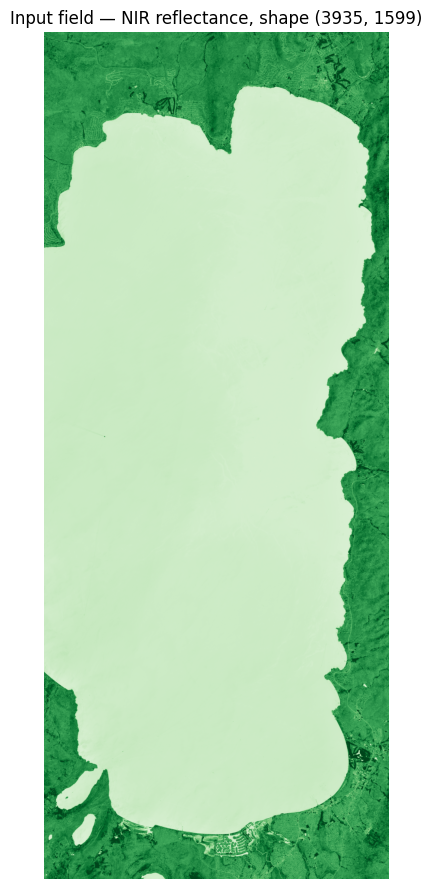

In [2]:
gt_bgrn = load_s2_chip(bbox=LAKE_TAHOE_BBOX)
print(f"S2 chip: shape={gt_bgrn.shape}  dtype={gt_bgrn.dtype}  crs={gt_bgrn.crs}")

nir_arr = np.asarray(gt_bgrn)[3].astype("float32") * 1e-4  # band-3 = NIR
gt = gt_bgrn.array_as_geotensor(nir_arr)  # (H, W) carrier
field = RasterField(gt)

fig, ax = plt.subplots(figsize=(7, 11))
ax.imshow(nir_arr, cmap="Greens", vmin=0, vmax=0.5)
ax.set_title(f"Input field — NIR reflectance, shape {nir_arr.shape}")
ax.axis("off")
plt.show()

## 2. The four-axis Patcher

256×256 `SpatialRectangular` patches, `SpatialRegularStride` of 256
(non-overlapping), `SpatialBoxcar` window (no taper), reconstruct via
`SpatialOverlapAdd`.

In [3]:
patcher = SpatialPatcher(
    geometry=SpatialRectangular(size=(256, 256)),
    sampler=SpatialRegularStride(step=256),
    window=SpatialBoxcar(),
    aggregation=SpatialOverlapAdd(),
)

patches = list(patcher.split(field))
print(f"len(patches): {len(patches)}")
print(f"patches[0].data.shape: {np.asarray(patches[0].data).shape}")
print(f"patches[0].anchor: {patches[0].anchor}")
print(f"patches[0].indices: {patches[0].indices}")

len(patches): 90
patches[0].data.shape: (256, 256)
patches[0].anchor: (0, 0)
patches[0].indices: Window(col_off=0, row_off=0, width=256, height=256)


## 3. A window gallery

Before running an operator, let's compare the five `SpatialWindow`
classes. Each `Window.weights(geometry)` returns an array shaped
like the patch — the multiplier `OverlapAdd` uses on the way in
(per-cell) and the denominator on the way out (sum-of-weights).

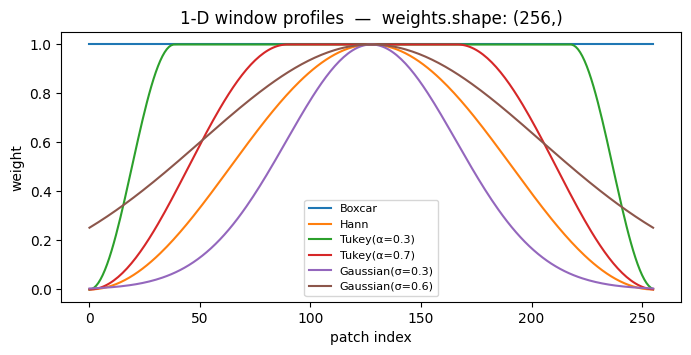

          Boxcar: weights.shape: (128, 128)
            Hann: weights.shape: (128, 128)
    Tukey(α=0.5): weights.shape: (128, 128)
 Gaussian(σ=0.4): weights.shape: (128, 128)


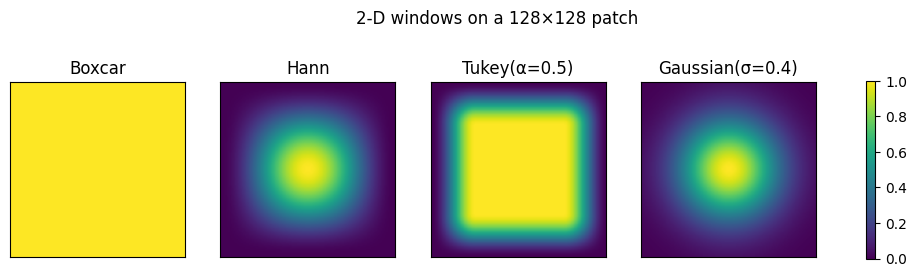

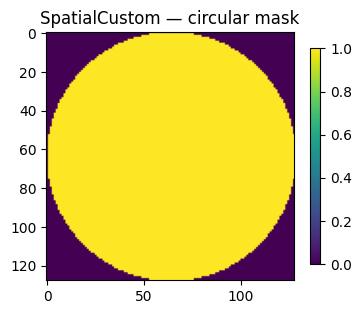

In [4]:
windows_1d = {
    "Boxcar": SpatialBoxcar(),
    "Hann": SpatialHann(),
    "Tukey(α=0.3)": SpatialTukey(alpha=0.3),
    "Tukey(α=0.7)": SpatialTukey(alpha=0.7),
    "Gaussian(σ=0.3)": SpatialGaussian(sigma=0.3),
    "Gaussian(σ=0.6)": SpatialGaussian(sigma=0.6),
}
geom1d = SpatialRectangular(size=(1, 256))
fig, ax = plt.subplots(figsize=(8, 3.5))
for name, w in windows_1d.items():
    weights = w.weights(geom1d).reshape(-1)
    ax.plot(weights, label=name)
ax.set_title("1-D window profiles  —  weights.shape: (256,)")
ax.set_xlabel("patch index")
ax.set_ylabel("weight")
ax.legend(fontsize=8)
plt.show()

# 2-D view — same windows on a 128×128 patch
windows_2d = {
    "Boxcar": SpatialBoxcar(),
    "Hann": SpatialHann(),
    "Tukey(α=0.5)": SpatialTukey(alpha=0.5),
    "Gaussian(σ=0.4)": SpatialGaussian(sigma=0.4),
}
geom2d = SpatialRectangular(size=(128, 128))
fig, axes = plt.subplots(1, 4, figsize=(13, 3.3))
for ax, (name, w) in zip(axes, windows_2d.items(), strict=True):
    weights = w.weights(geom2d)
    print(f"{name:>16s}: weights.shape: {weights.shape}")
    im = ax.imshow(weights, vmin=0, vmax=1, cmap="viridis")
    ax.set_title(name)
    ax.set_xticks([])
    ax.set_yticks([])
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.7)
plt.suptitle("2-D windows on a 128×128 patch")
plt.show()

# `SpatialCustom` is the escape hatch — pass any callable
ring = SpatialCustom(
    fn=lambda g: (
        ((np.indices(g.size) - np.array(g.size)[:, None, None] / 2) ** 2).sum(axis=0)
        < (g.size[0] / 2) ** 2
    )
)
plt.figure(figsize=(4, 4))
plt.imshow(ring.weights(geom2d), cmap="viridis")
plt.title("SpatialCustom — circular mask")
plt.colorbar(shrink=0.7)
plt.show()

## 4. Per-chip operator: invert the gradient

A tiny `Lambda` operator that maps `x → 0.5 - x`. Inside each
256×256 chip it inverts the NIR-reflectance gradient — vegetation
becomes dark, water becomes bright. Watching this run gives us a
clean visual sanity check that the patches land in the right
anchors and stitch back without seams.

len(out_patches): 90
out_patches[0].data.shape: (256, 256)


stitched.shape: (3935, 1599)


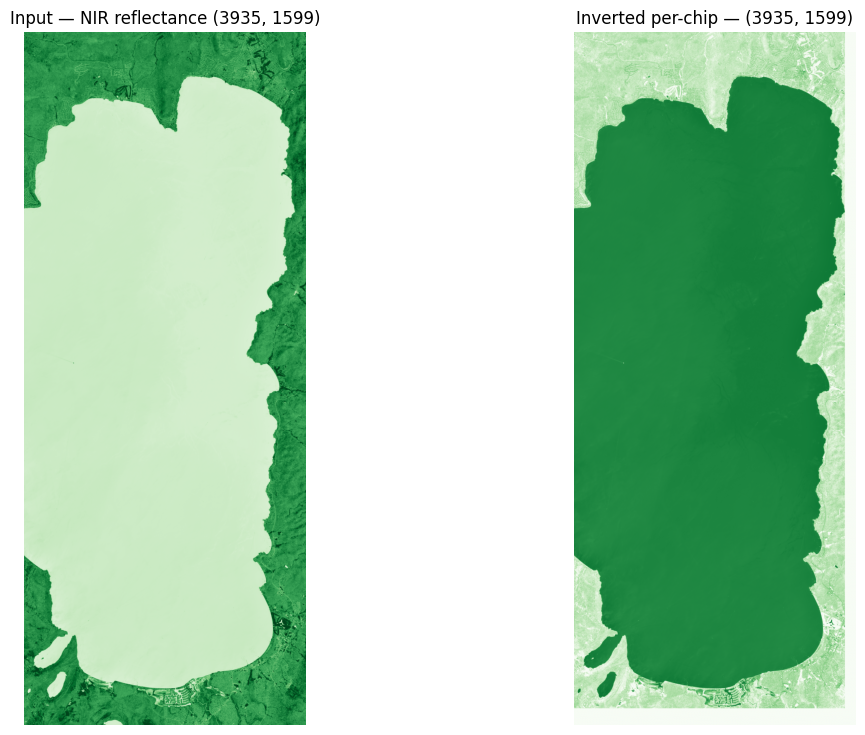

In [5]:
invert = Lambda(lambda gt: 0.5 - np.asarray(gt), name="invert")

out_patches = ApplyToChips(invert)(patches)
print(f"len(out_patches): {len(out_patches)}")
print(f"out_patches[0].data.shape: {out_patches[0].data.shape}")

stitched = patcher.aggregation.merge(out_patches, field.reader)
print(f"stitched.shape: {stitched.shape}")

fig, axes = plt.subplots(1, 2, figsize=(13, 9))
axes[0].imshow(nir_arr, cmap="Greens", vmin=0, vmax=0.5)
axes[0].set_title(f"Input — NIR reflectance {nir_arr.shape}")
axes[0].axis("off")
axes[1].imshow(stitched, cmap="Greens", vmin=0, vmax=0.5)
axes[1].set_title(f"Inverted per-chip — {stitched.shape}")
axes[1].axis("off")
plt.show()

## 5. Composition with `Sequential`

Same loop expressed as a three-operator linear pipeline using the
`gz.patch_ops` wrappers. This is how the `SpatialPatcher` slots into
the broader composition algebra.

In [6]:
pipe = Sequential(
    [
        GridSampler(patcher),
        ApplyToChips(invert),
        Stitch(SpatialOverlapAdd(), domain=field.reader),
    ]
)
result = pipe(field)
print(f"result.shape: {result.shape}")
np.testing.assert_allclose(np.asarray(result), stitched)
print("`Sequential` and the manual loop produce identical output ✓")

result.shape: (3935, 1599)


`Sequential` and the manual loop produce identical output ✓


## 6. Hann window + overlap

Swap to a Hann window with stride < patch size. The `OverlapAdd`
aggregation now normalises by the accumulated weights so the seams
blend cleanly. Watch the seam between adjacent chips — it disappears
entirely.

out2.shape: (3935, 1599)


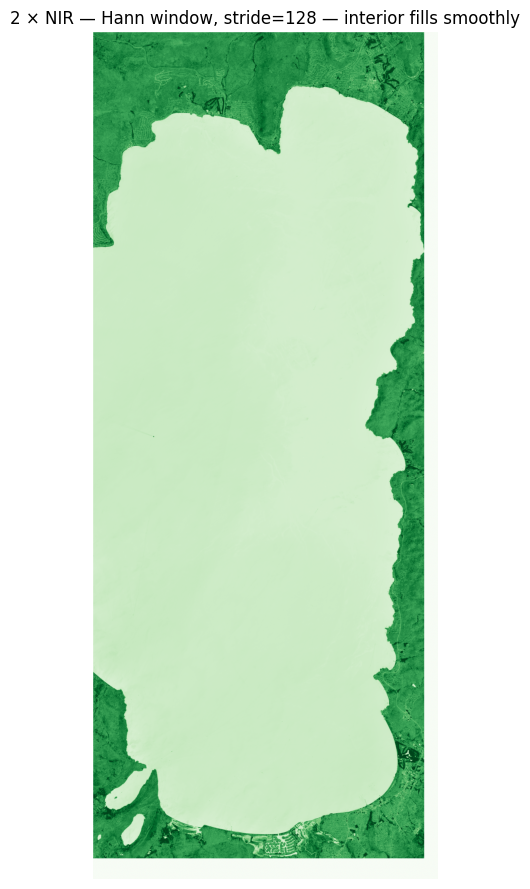

In [7]:
overlap_patcher = SpatialPatcher(
    geometry=SpatialRectangular(size=(256, 256)),
    sampler=SpatialRegularStride(step=128),  # 50 % overlap
    window=SpatialHann(),
    aggregation=SpatialOverlapAdd(),
)
double = Lambda(lambda gt: np.asarray(gt) * 2.0, name="double")

pipe2 = Sequential(
    [
        GridSampler(overlap_patcher),
        ApplyToChips(double),
        Stitch(SpatialOverlapAdd(), domain=field.reader),
    ]
)
out2 = np.asarray(pipe2(field))
print(f"out2.shape: {out2.shape}")

fig, ax = plt.subplots(figsize=(7, 11))
ax.imshow(out2, cmap="Greens", vmin=0, vmax=1.0)
ax.set_title("2 × NIR — Hann window, stride=128 — interior fills smoothly")
ax.axis("off")
plt.show()

## 7. `get_config()` round-trip

Every axis (and the `SpatialPatcher` itself) returns a JSON-serialisable
`get_config()` dict — the audit-trail artifact that lets you persist a
pipeline as YAML or hash it for regulatory reproducibility.

In [8]:
print(json.dumps(patcher.get_config(), indent=2))

{
  "geometry": {
    "class": "SpatialRectangular",
    "config": {
      "size": [
        256,
        256
      ]
    }
  },
  "sampler": {
    "class": "SpatialRegularStride",
    "config": {
      "step": 256
    }
  },
  "window": {
    "class": "SpatialBoxcar",
    "config": {}
  },
  "aggregation": {
    "class": "SpatialOverlapAdd",
    "config": {
      "streaming": false,
      "target_path": null,
      "chunks": null,
      "normalize_by_window": true
    }
  }
}


## Where next

- **[02_geometries](02_geometries.ipynb)** — the five geometry classes (Rectangular, SphericalCap, KNNGraph, RadiusGraph, PolygonIntersection) on real heterogeneous substrates.
- **[03_sampling](03_sampling.ipynb)** — the sampler gallery (RegularStride, JitteredStride, Random, PoissonDisk, Explicit).
- **[06_streaming](06_streaming.ipynb)** — same patcher pattern but at *full S2 tile* scale (~10980² px) using a zarr-backed `SpatialOverlapAdd`.
- **[../05_patching_grids](../05_patching_grids.ipynb)** — the applied walkthrough version: NDVI over Lake Tahoe with a real per-chip operator stack.